# Model Evaluation and Validation

# Why Split Data into Training and Test Datasets?

## Introduction
When developing machine learning models, one of the key steps is to split the available data into training and test datasets. This practice is crucial for several reasons, which will be outlined below.

## Reasons for Splitting Data

### 1. **Model Evaluation**

### 2. **Overfitting Prevention**

### 3. **Model Tuning**

### 4. **Cross-validation**

### 5. **Fair Comparison**

In [69]:
import pandas as pd

# Load the CO2 dataset
df = pd.read_csv("https://nyc3.digitaloceanspaces.com/owid-public/data/co2/owid-co2-data.csv")

# Filter data for the USA
df = df[df['iso_code'] == 'USA']

# Extract and set the 'year' column as the index with DateTime format
df['year'] = pd.to_datetime(df['year'], format='%Y')
df.dropna(inplace=True)
df.set_index('year', inplace=True)

# Select the 'co2' column for monthly average CO2 levels
co2_monthly = df['co2'].resample('Y').mean()

# Display the first few rows of the yearly average CO2 levels
print(co2_monthly.head())

# Determine the split point (e.g., using a specific year)
split_year = pd.to_datetime('2000-01-01')

# Split the data into train and test sets based on the split point
train = co2_monthly[co2_monthly.index < split_year]
test = co2_monthly[co2_monthly.index >= split_year]

# Display the shapes of the train and test sets
print("Train set shape:", train.shape)
print("Test set shape:", test.shape)


year
1990-12-31    5120.957
1991-12-31    5062.957
1992-12-31    5174.228
1993-12-31    5272.851
1994-12-31    5364.279
Freq: A-DEC, Name: co2, dtype: float64
Train set shape: (10,)
Test set shape: (19,)


In [71]:
train.sort_index(inplace = True)
train.head()

year
1990-12-31    5120.957
1991-12-31    5062.957
1992-12-31    5174.228
1993-12-31    5272.851
1994-12-31    5364.279
Freq: A-DEC, Name: co2, dtype: float64

<AxesSubplot:xlabel='year'>

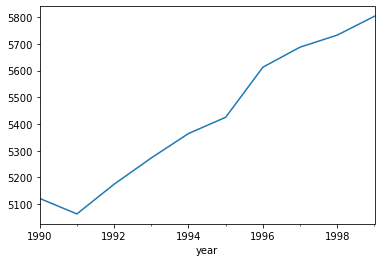

In [73]:
train.plot()

In [75]:
from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm

# Ensure the data is appropriate for modeling
train.dropna(inplace= True) # Drop any missing values

# Fit an Autoregressive Model (AR model)
ar_model = sm.tsa.ARIMA(train, order=(1, 0, 1))
ar_result = ar_model.fit()

print(ar_result.summary())

                               SARIMAX Results                                
Dep. Variable:                    co2   No. Observations:                   10
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 -59.702
Date:                Mon, 22 Jan 2024   AIC                            127.405
Time:                        11:31:38   BIC                            128.615
Sample:                    12-31-1990   HQIC                           126.077
                         - 12-31-1999                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5475.2855    265.303     20.638      0.000    4955.302    5995.269
ar.L1          0.9140      0.199      4.593      0.000       0.524       1.304
ma.L1          0.4831      0.794      0.608      0.5

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


In [79]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Ensure the data is appropriate for modeling
train.dropna(inplace=True)  # Drop missing values from the training data

# Fit an Autoregressive Integrated Moving Average (ARIMA) Model
arima_model = ARIMA(train, order=(1, 0, 1))
arima_result = arima_model.fit()

# Predictions
# Manually set the frequency of the time series data if it's known
freq = 'Y'  # Replace 'D' with the appropriate frequency of your data

# Calculate the start and end points for predictions
start = train.index[-1] + pd.tseries.frequencies.to_offset(freq)
end = start + (len(test) - 1) * pd.tseries.frequencies.to_offset(freq)

predictions = arima_result.predict(start=start, end=end, dynamic=False)

# Ensure your 'test' data is prepared similarly to 'train' data
test_prepared = test.dropna()

# Compute MSE, RMSE, and MAPE
mse = mean_squared_error(test_prepared, predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test_prepared - predictions) / test_prepared)) * 100

print("MSE:", mse)
print("RMSE:", rmse)
print("MAPE:", mape)

MSE: 71385.89589774642
RMSE: 267.1813913762454
MAPE: 4.043139371254876


/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


# Understanding Error Metrics: MSE, RMSE, and MAPE

## Mean Squared Error (MSE)
- **Formula:** 
  $ \text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(Y_i - \hat{Y}_i)^2 $
  
## Root Mean Squared Error (RMSE)
- **Formula:** 
  $ \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(Y_i - \hat{Y}_i)^2} $

## Mean Absolute Percent Error (MAPE)
- **Formula:** 
  $ \text{MAPE} = \frac{100\%}{n}\sum_{i=1}^{n} \left| \frac{Y_i - \hat{Y}_i}{Y_i} \right| $
- **Interpretation:** MAPE is easy to interpret as a percentage. Lower values of MAPE indicate better fit. MAPE is scale-independent, making it particularly useful for comparing accuracy across different datasets.